In [1]:
import logging
import os
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from IPython.display import Image, display

import scarf
from scarf.agent import (
    AnalysisConfig,
    RuntimeConfig,
    Study,
    analyze_rna_async,
    resume_rna_async,
)

env_file = os.environ.get("SCARF_AGENT_ENV_FILE")
_ = load_dotenv(env_file) if env_file else load_dotenv()
work_dir = Path(os.environ.get("SCARF_AGENT_NOTEBOOK_DIR", Path.cwd())).resolve()
work_dir.mkdir(parents=True, exist_ok=True)
os.chdir(work_dir)
scarf.configure_output(level="WARNING", progress=False)
logging.getLogger("huggingface_hub").setLevel(logging.CRITICAL)

dataset_id = "garridotrigo_2023_ibd_hc_10x_single_cell_transcriptomics_data_9bfecd44"
data_path = work_dir / "data.zarr"
run_dir = work_dir / "agent_runs" / "garrido-trigo"

In [2]:
from huggingface_hub import BucketFile, download_bucket_files, get_token, list_bucket_tree
from huggingface_hub.utils import disable_progress_bars

from scarf import cytebase
from scarf.tools.repack_zarr import repack_store

if not data_path.exists():
    catalog = cytebase.Catalog()
    entry = catalog.dataset(dataset_id)
    source_uri = entry.row["zarr_uri"]
    if not source_uri.startswith("hf://buckets/"):
        raise ValueError("This copy recipe expects a Cytebase HF bucket source")
    pieces = source_uri.removeprefix("hf://buckets/").split("/")
    bucket, prefix = "/".join(pieces[:2]), "/".join(pieces[2:]).rstrip("/") + "/"
    raw_path = work_dir / "scarf_datasets" / f"{dataset_id}.zarr"
    raw_path.mkdir(parents=True, exist_ok=True)
    disable_progress_bars()
    token = get_token() or False
    objects = [
        item for item in list_bucket_tree(bucket, prefix=prefix, recursive=True, token=token)
        if isinstance(item, BucketFile)
    ]
    transfers = []
    for item in objects:
        if not item.path.startswith(prefix):
            raise ValueError("A source object is outside the dataset prefix")
        relative = Path(item.path.removeprefix(prefix))
        if relative.is_absolute() or ".." in relative.parts or not relative.parts:
            raise ValueError("Invalid source object path")
        transfers.append((item, raw_path / relative))
    if not transfers:
        raise ValueError("The published source contains no downloadable files")
    download_bucket_files(bucket, transfers, token=token, raise_on_missing_files=True)
    repack_store(
        str(raw_path), str(data_path), data_only=True,
        profile="fast_local", nthreads=4, mem_budget="4G",
    )

store = scarf.DataStore(
    str(data_path), zarr_mode="r", min_features_per_cell=-1,
    nthreads=4, mem_budget="4G",
)
input_cells = store.cells.fetch_all("I").copy()
input_ids = store.cells.fetch_all("ids").copy()
input_features = store.RNA.feats.fetch_all("ids").copy()
print({"dataset": dataset_id, "cells": int(input_cells.sum()), "genes": len(input_features)})

  RNA/counts: shape=(46700, 32354), dtype=float32, chunks=(4671, 2676), shards=(4671, 34788)


{'dataset': 'garridotrigo_2023_ibd_hc_10x_single_cell_transcriptomics_data_9bfecd44', 'cells': 46700, 'genes': 32354}


In [3]:
columns = set(store.cells.columns)
metadata_facts = {}
for name in ("organism", "tissue", "disease", "donor_id", "sample_id"):
    if name in columns:
        values = store.cells.to_pandas_dataframe([name])[name]
        counts = values.dropna().astype(str).value_counts()
        metadata_facts[name] = {
            "distinct": len(counts),
            "missing": int(values.isna().sum()),
            "levels": {str(key): int(value) for key, value in counts.head(20).items()},
        }

import json

study = Study(
    context=(
        "Garrido-Trigo 2023 IBD and healthy-control intestinal RNA cohort from Cytebase. "
        "Describe the supplied populations with measured markers. Author labels are held out. "
        "No technical batch correction or doublet scoring is authorized. "
        "Donors are biological identities; missing capture or replication details do not "
        "block descriptive analysis. Do not make disease-comparison or causal claims.\n"
        "Observed source metadata: " + json.dumps(metadata_facts, ensure_ascii=False)
    ),
    objective="Identify defensible major cell populations and report provisional identities and uncertainty.",
    organism="Homo sapiens",
    sampleColumn="donor_id" if "donor_id" in columns else None,
    protectedColumns=[name for name in ("disease", "tissue", "sex") if name in columns],
    excludedColumns=[name for name in columns if name.lower().startswith(("skill_", "agent_"))],
)
del store

In [4]:
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.openai import OpenAIProvider

api_key = os.environ.get("AGENT_API_KEY")
model = None
if api_key:
    model = OpenAIChatModel(
        "deepseek-ai/DeepSeek-V4.1-Flash",
        provider=OpenAIProvider(base_url="https://inference.baseten.co/v1", api_key=api_key),
    )
runtime = RuntimeConfig(nthreads=4, memBudget="4G")
if run_dir.exists():
    run = await resume_rna_async(run_dir, model=model, runtime=runtime)
else:
    if model is None:
        raise RuntimeError("Configure AGENT_API_KEY before starting a fresh analysis")
    run = await analyze_rna_async(
        data_path, run_dir=run_dir, model=model, study=study,
        config=AnalysisConfig(assay="RNA"), runtime=runtime,
    )
if run.status != "completed":
    raise RuntimeError(f"Analysis returned {run.status}; inspect its saved report before continuing")
print({"status": run.status, "pipelineInvocations": len(run.pipeline_runs)})

{'status': 'completed', 'pipelineInvocations': 7}


In [5]:
display(pd.DataFrame(run.exploration_coverage["slots"]))
display(pd.DataFrame(run.annotations)[["clusterId", "identity", "confidence", "rationale"]])

,axis,candidateId,parameters,parentId,reason,status
0,baseline,c0,"{'candidateId': 'c0', 'hvgCount': 1000, 'neigh...",NaN,None,measured
1,hvgCount,c1,"{'candidateId': 'c1', 'hvgCount': 2000, 'neigh...",c0,None,measured
2,pcaDims,c2,"{'candidateId': 'c2', 'hvgCount': 1000, 'neigh...",c0,None,measured
3,neighborsK,c3,"{'candidateId': 'c3', 'hvgCount': 1000, 'neigh...",c0,None,measured


,clusterId,identity,confidence,rationale
0,1,T cells (activated/regulatory-like),medium,"Multiple T-cell markers qualify (ICOS, CD28, C..."
1,10,unassigned,low,Only CFTR (0.49) reaches 2-marker threshold we...
2,11,unassigned,low,"DUOX2/DUOXA2 qualify (score>0.6, fracExp>0.2) ..."
3,12,enterocytes (colonocyte-like),high,"Strong absorptive colonocyte markers (AQP8, GU..."
4,13,goblet cells,high,"Goblet markers MUC2, ITLN1, CLCA1, SPINK4 stro..."
5,14,macrophages (C1Q+),high,Complement and macrophage markers C1QA/B/C plu...
6,15,neutrophils,high,"Neutrophil markers FCGR3B, CSF3R, S100A8, FPR2..."
7,16,monocytes (classical/non-classical),high,"Monocyte markers FCN1, CD300E, LILRB2, LILRA5,..."
8,17,Mast cells,high,"Tryptase TPSAB1/TPSB2, CPA3, MS4A2 and HDC are..."
9,18,Tuft cells,medium,"TRPM5, SH2D6 and IL17RB co-expression fits che..."


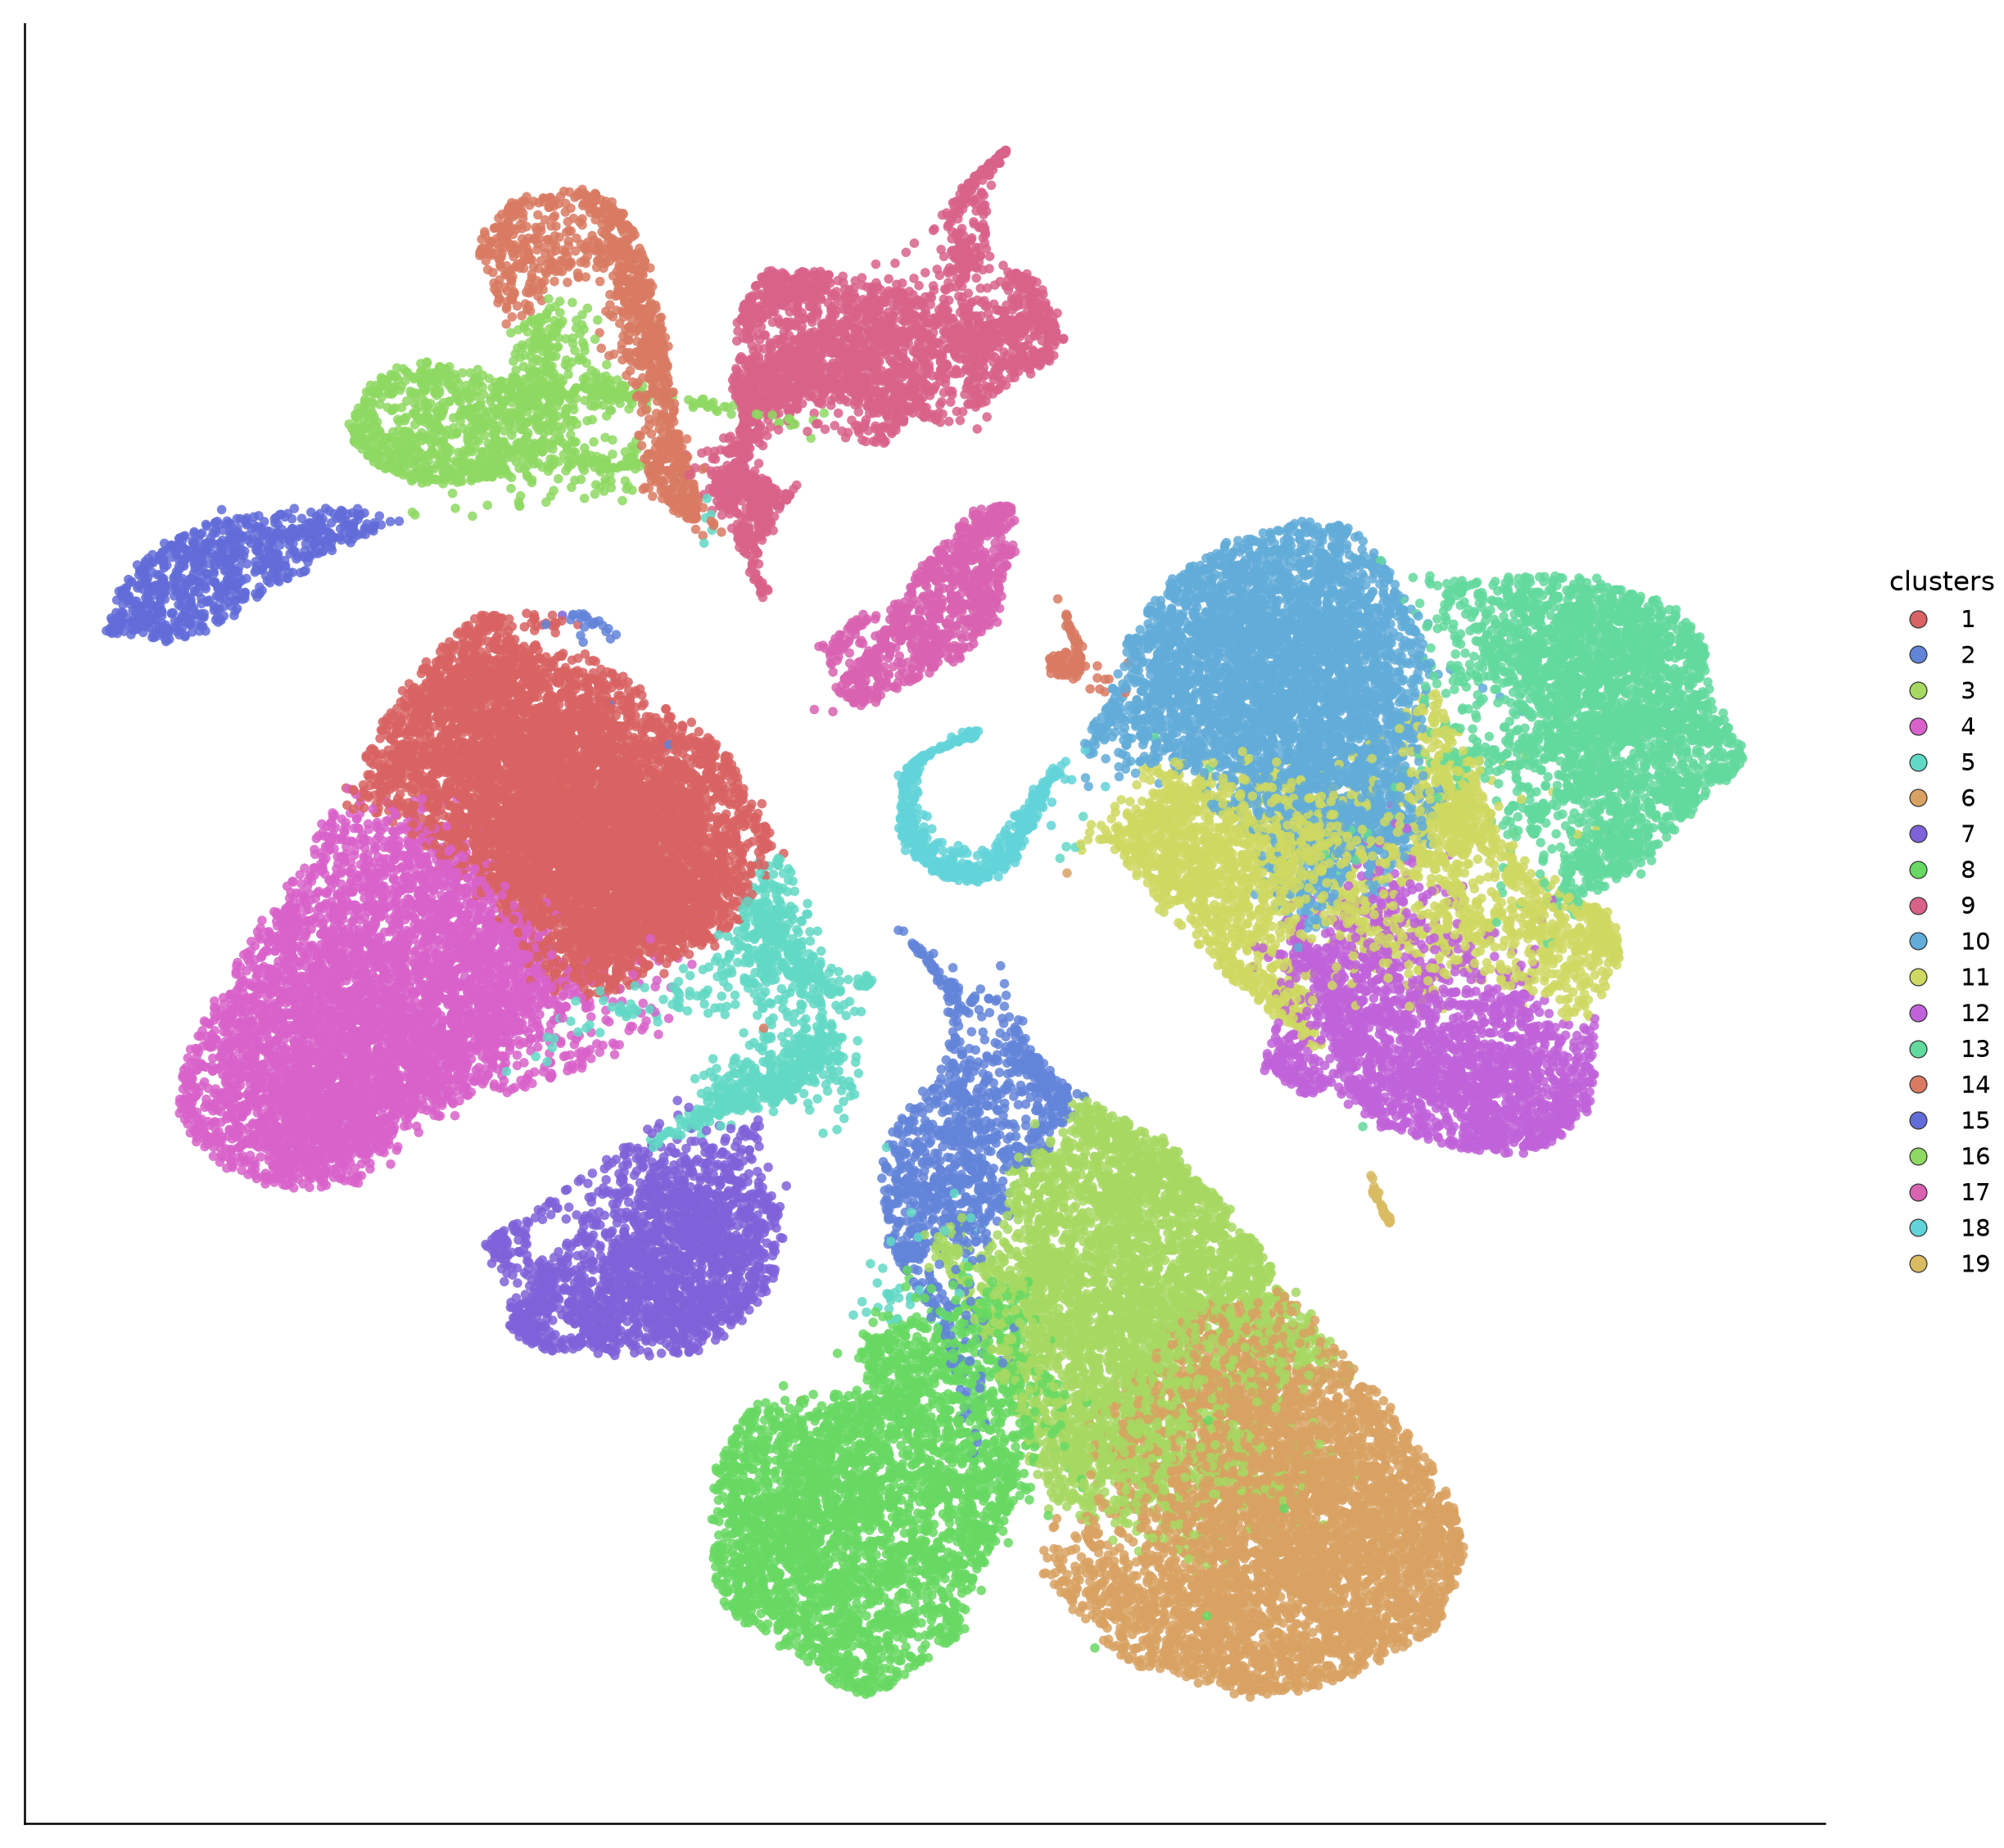

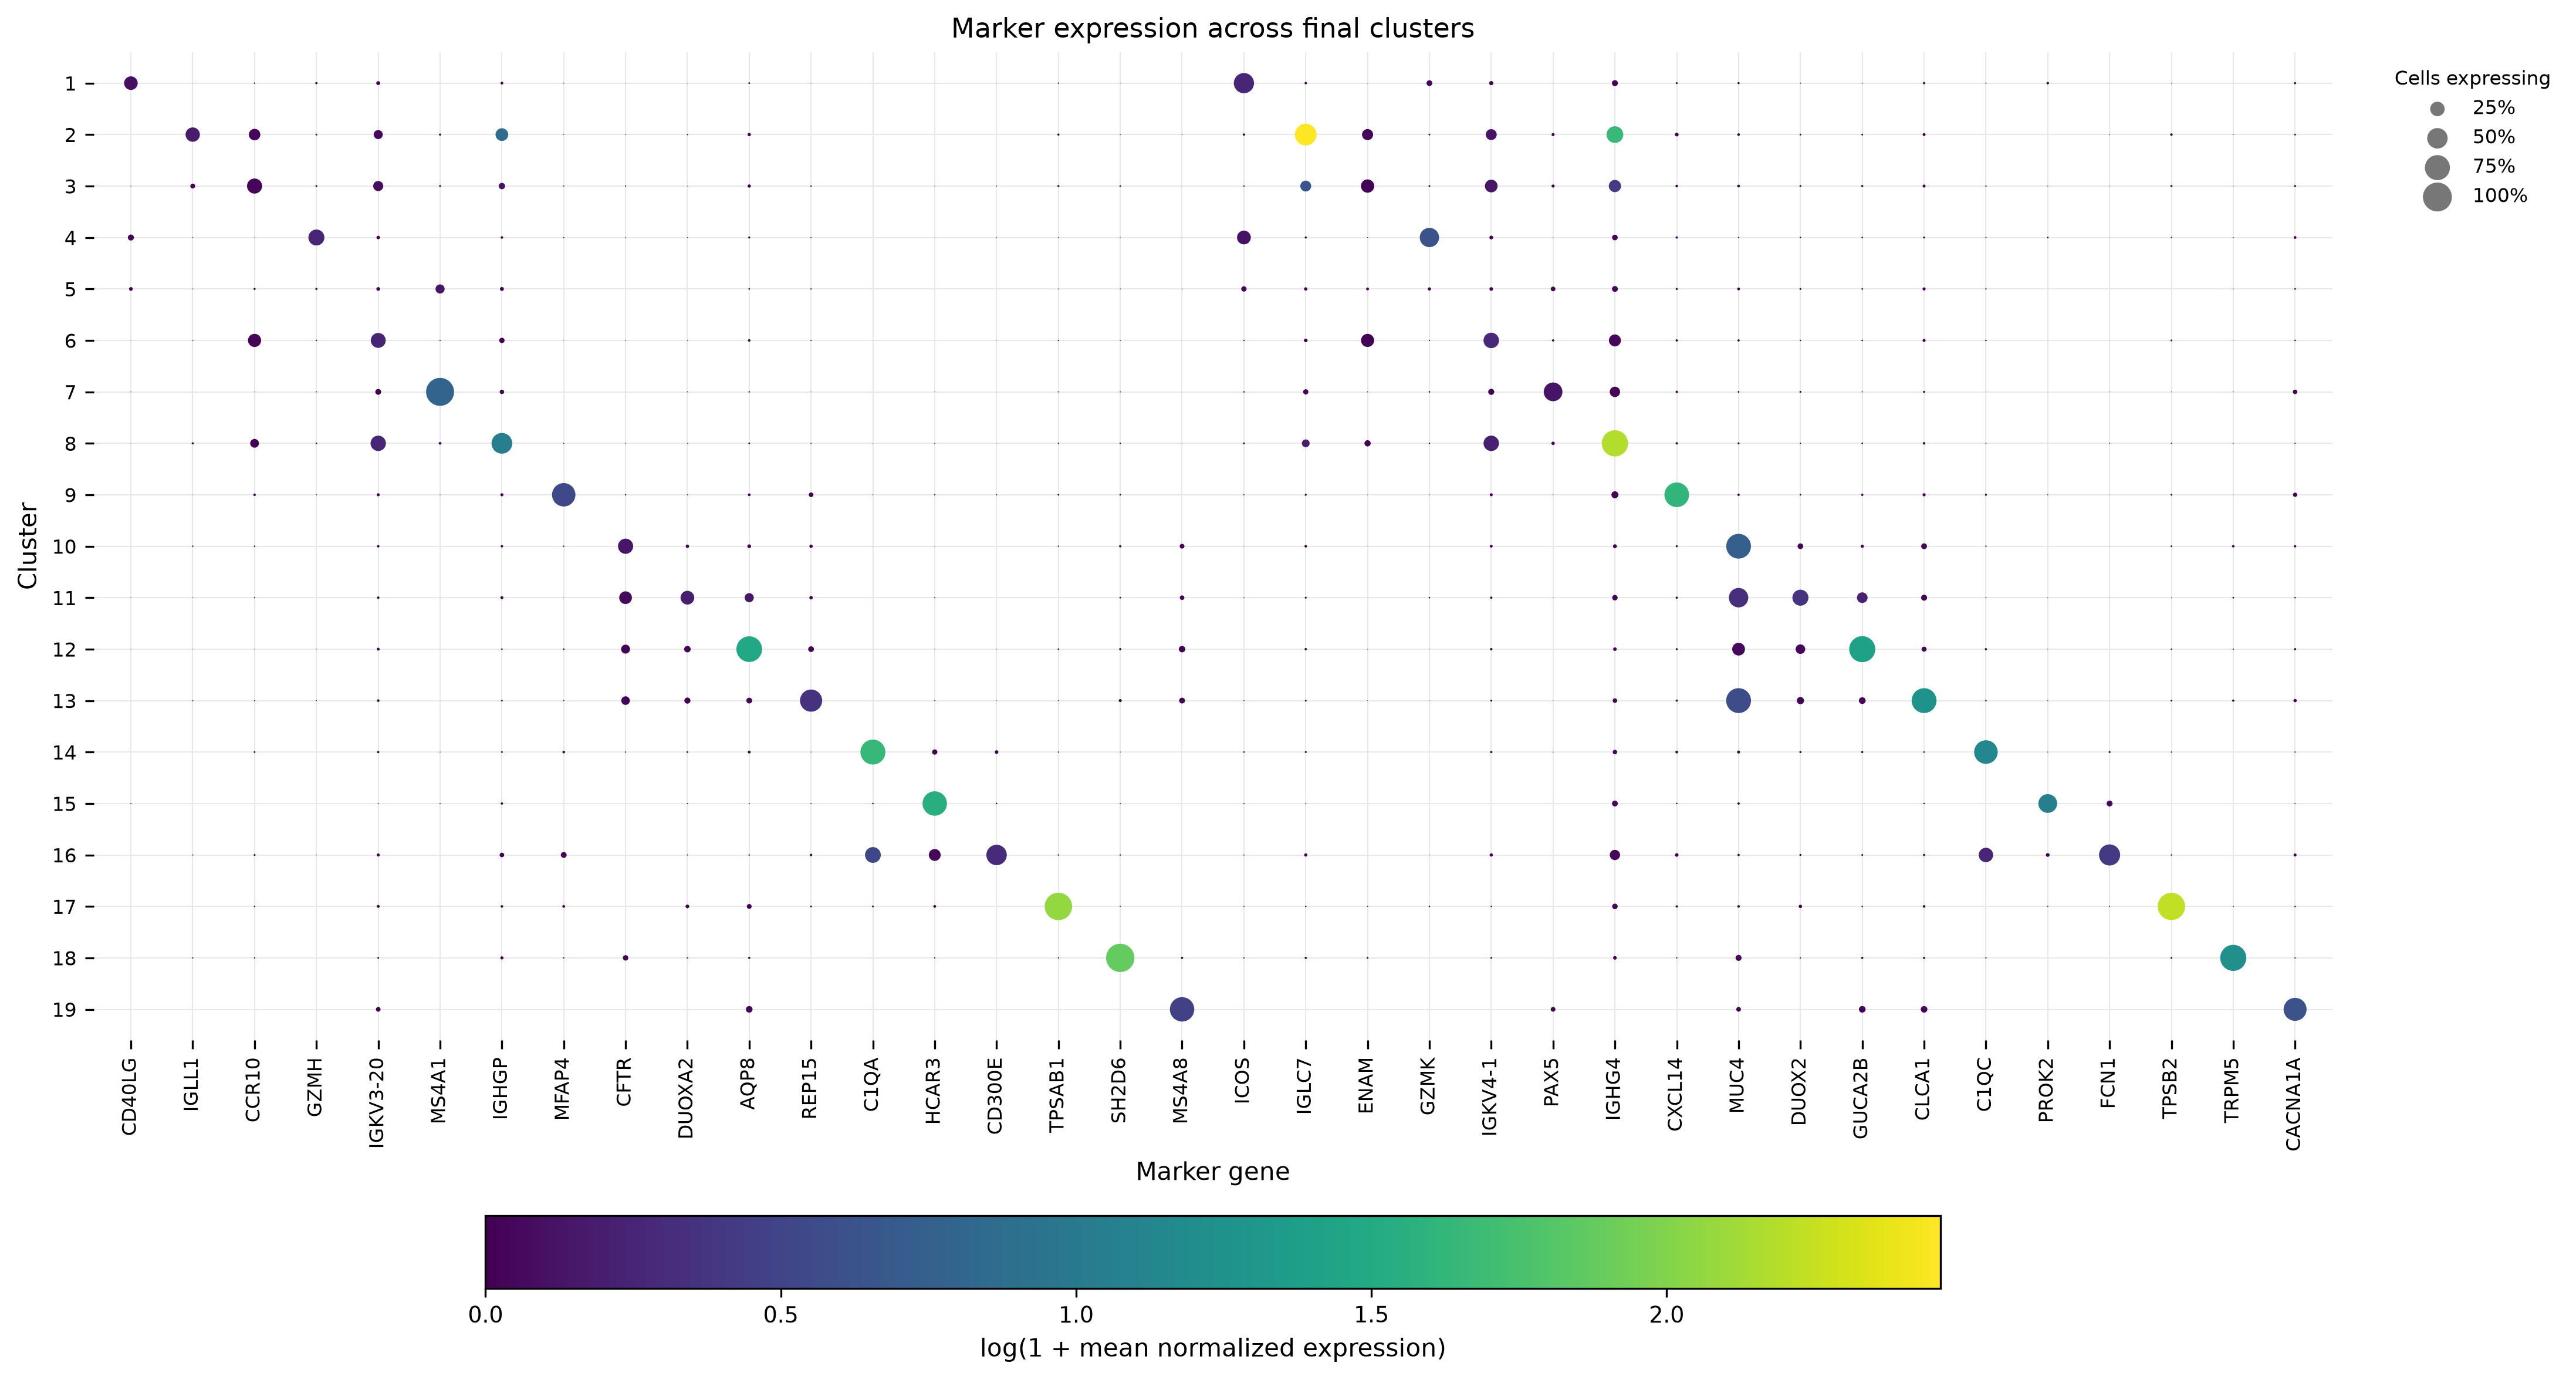

In [6]:
display(Image(filename=str(run.run_dir / "umap_clusters.png")))
display(Image(filename=str(run.run_dir / "marker_dotplot.png")))

In [7]:
import numpy as np

compact = run.compact_result
assert compact is not None
assert compact["finalPipelineRunId"] == run.pipeline.run_id
selected = compact["selectedParameters"]
display(pd.Series({
    key: selected[key]
    for key in ("requestedHvgCount", "actualHvgCount", "pcaDims", "neighborsK", "resolution", "useHarmony")
}, name="Final settings").to_frame())
verification = scarf.DataStore(str(data_path), zarr_mode="r", min_features_per_cell=-1)
assert np.array_equal(verification.cells.fetch_all("I"), input_cells)
assert np.array_equal(verification.cells.fetch_all("ids"), input_ids)
assert np.array_equal(verification.RNA.feats.fetch_all("ids"), input_features)
replayed = run.replay_decisions()
assert all(item["valid"] for item in replayed)
print({
    "compactResultStored": True,
    "pipelineReferenceVerified": True,
    "inputCohortUnchanged": True,
    "decisionsReplayed": len(replayed),
})
print("Report:", run.report().relative_to(work_dir))

,Final settings
requestedHvgCount,1000
actualHvgCount,1000
pcaDims,21
neighborsK,21
resolution,0.75
useHarmony,False


{'compactResultStored': True, 'pipelineReferenceVerified': True, 'inputCohortUnchanged': True, 'decisionsReplayed': 7}


Report: agent_runs/garrido-trigo/report.html
